In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")
calendario = pd.read_excel("DIM_CALENDAR (2).xlsx")
calendario

,WEEK,YEAR,MONTH,WEEK_NUMBER,DATE
0,01-21,2021,1,1,2021-01-10
1,02-21,2021,1,2,2021-01-17
2,03-21,2021,1,3,2021-01-24
3,04-21,2021,1,4,2021-01-31
4,05-21,2021,2,5,2021-02-07
...,...,...,...,...,...
151,48-23,2023,12,48,2023-12-04
152,49-23,2023,12,49,2023-12-11
153,50-23,2023,12,50,2023-12-18
154,51-23,2023,12,51,2023-12-25


In [33]:
segmento = pd.read_excel("DIM_SEGMENT (1).xlsx")
segmento.head()

,CATEGORY,ATTR1,ATTR2,ATTR3,FORMAT,SEGMENT
0,1,CLORO,CLORO,BAMBINO,LIQUIDO,BLEACH
1,1,CLORO,CLORO,GERMICIDA,LIQUIDO,BLEACH
2,1,CLORO,CLORO,MASCOTAS,LIQUIDO,BLEACH
3,1,CLORO,CLORO,MULTIUSOS,GEL,BLEACH
4,1,CLORO,CLORO,MULTIUSOS,LIQUIDO,BLEACH


In [49]:
product = pd.read_excel("DIM_PRODUCT (1).xlsx")
product.head()

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
3,INDS. ALEN,CLORALEX,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
4,INDS. ALEN,CLORALEX,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [27]:
sales = pd.read_csv("FACT_SALES (1).csv")
sales

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5
...,...,...,...,...,...,...
121997,26-23,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO
121998,26-23,7501058757630,1.947,235.416,2.797,TOTAL AUTOS SCANNING MEXICO
121999,26-23,7501058753441,18.013,429.289,9.102,TOTAL AUTOS SCANNING MEXICO
122000,26-23,7702626204208BP1,21.152,210.276,22.172,TOTAL AUTOS SCANNING MEXICO


In [55]:
df_master = pd.merge(sales, product, left_on='ITEM_CODE', right_on='ITEM', how='left')

columnas_cruce = ['CATEGORY', 'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3']

df_master = pd.merge(df_master, segmento, on=columnas_cruce, how='left')


df_master = pd.merge(df_master, calendario, on='WEEK', how='left')

df_master = df_master.drop(columns=['ITEM'])


print(f"Filas totales de la tabla maestra: {df_master.shape[0]}")
df_master.head()

Filas totales de la tabla maestra: 122002


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT,YEAR,MONTH,WEEK_NUMBER,DATE
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,2022,8,34,2022-08-28
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,2022,8,34,2022-08-28
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,2022,8,34,2022-08-28
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,2022,8,34,2022-08-28
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,2022,8,34,2022-08-28


In [61]:
df_vanish = df_master[df_master['BRAND'] == 'VANISH'].copy()

print(f"Total de registros de ventas de Vanish: {df_vanish.shape[0]}")
print(f"Total de productos (SKUs) distintos de Vanish: {df_vanish['ITEM_CODE'].nunique()}")
display(df_vanish.head())

Total de registros de ventas de Vanish: 28377
Total de productos (SKUs) distintos de Vanish: 77


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT,YEAR,MONTH,WEEK_NUMBER,DATE
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,2022,8,34,2022-08-28
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,2022,8,34,2022-08-28
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,2022,8,34,2022-08-28
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,2022,8,34,2022-08-28
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,2022,8,34,2022-08-28


In [69]:
skus_stats = df_vanish.groupby('ITEM_CODE').agg(
    Ingresos_Totales=('TOTAL_VALUE_SALES', 'sum'),
    Unidades_Totales=('TOTAL_UNIT_SALES', 'sum'),
    Frecuencia_Ventas=('WEEK', 'count') 
).reset_index()

skus_stats['Precio_Promedio'] = skus_stats['Ingresos_Totales'] / skus_stats['Unidades_Totales']

columnas_catalogo = ['ITEM_CODE', 'ITEM_DESCRIPTION', 'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3', 'SEGMENT']
catalogo_vanish = df_vanish[columnas_catalogo].drop_duplicates(subset=['ITEM_CODE'])

portafolio_vanish = pd.merge(skus_stats, catalogo_vanish, on='ITEM_CODE', how='left')

portafolio_vanish_top = portafolio_vanish.sort_values(by='Ingresos_Totales', ascending=False)

print(f"Lista de SKUs para el clustering: {portafolio_vanish.shape[0]}")
display(portafolio_vanish_top.head())

Lista de SKUs para el clustering: 77


,ITEM_CODE,Ingresos_Totales,Unidades_Totales,Frecuencia_Ventas,Precio_Promedio,ITEM_DESCRIPTION,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT
70,7503002319529,162102.968,2937.696,560,55.180307,VANISH LIQUIDO BOTELLA 925ML NAL. 7503002319529,LIQUIDO,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL
25,7501058717023,158725.720,7024.094,560,22.597323,VANISH ROSA QUITAMANCHAS GEL MULTIUSOS POUCH 4...,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL
20,7501058716767,132086.569,874.500,532,151.042389,VANISH ROSA QUITAMANCHAS GEL BOT 3.8 LT PROM E...,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL
26,7501058717030,114642.364,5046.584,560,22.716825,VANISH CRYSTAL WHITE QUITAMANCHAS GEL POUCH 45...,GEL,SAFE BLEACH,FABRIC TREATMENT,BLANCO,LIQUID & GEL
40,7501058757890,111346.252,1187.546,560,93.761633,VANISH PODER O2 CRYSTAL WHITE BOTE 450 GR 750...,POLVO,SAFE BLEACH,FABRIC TREATMENT,BLANCO,POWDER


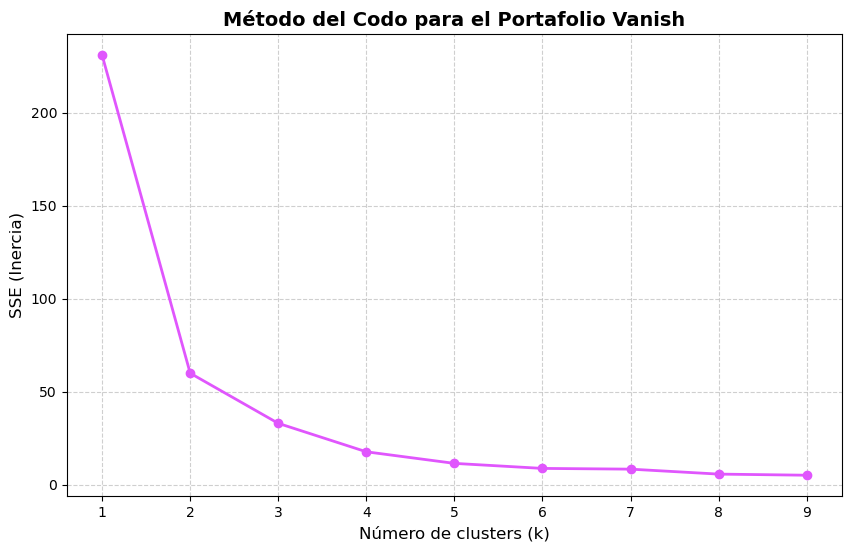

In [71]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

metricas = ['Ingresos_Totales', 'Unidades_Totales', 'Frecuencia_Ventas']

for col in metricas:
    portafolio_vanish[f'{col}_Log'] = np.log1p(portafolio_vanish[col])

scaler = StandardScaler()
columnas_log = ['Ingresos_Totales_Log', 'Unidades_Totales_Log', 'Frecuencia_Ventas_Log']

datos_escalados = scaler.fit_transform(portafolio_vanish[columnas_log])

df_clustering = pd.DataFrame(datos_escalados, columns=columnas_log)

sse_portafolio = {}

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_clustering)
    sse_portafolio[k] = kmeans.inertia_

plt.figure(figsize=(10,6))
plt.plot(list(sse_portafolio.keys()), list(sse_portafolio.values()), marker='o', linewidth=2, color='#e056fd') 

plt.title('Método del Codo para el Portafolio Vanish', fontsize=14, fontweight='bold')
plt.xlabel("Número de clusters (k)", fontsize=12)
plt.ylabel("SSE (Inercia)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [75]:
kmeans_portafolio = KMeans(n_clusters=4, random_state=42)
portafolio_vanish['Cluster'] = kmeans_portafolio.fit_predict(df_clustering)

radiografia_clusters = portafolio_vanish.groupby('Cluster').agg(
    Cantidad_SKUs=('ITEM_CODE', 'count'),
    Promedio_Ingresos=('Ingresos_Totales', 'mean'),
    Promedio_Unidades=('Unidades_Totales', 'mean'),
    Promedio_Frecuencia=('Frecuencia_Ventas', 'mean')
).round(2)

radiografia_clusters = radiografia_clusters.sort_values(by='Promedio_Ingresos')
display(radiografia_clusters)

,Cantidad_SKUs,Promedio_Ingresos,Promedio_Unidades,Promedio_Frecuencia
Cluster,,,,
3,12,1.11,0.03,15.33
1,14,44.70,1.23,158.36
2,21,4538.57,57.47,452.29
0,30,69078.01,1803.61,549.27


Cluster 0 (30 SKUs):

Diagnóstico: Generan un promedio de $69,078 en ingresos y mueven más de 1,800 unidades. Tienen la frecuencia más alta (549).

Estrategia: Aquí está el dinero de la marca. Nunca deben quedarse sin stock. Son los formatos que la gente ama.

Cluster 2 (21 SKUs):

Diagnóstico: Productos muy sólidos. Aparecen casi tan frecuente como el cluster 0 (frecuencia de 452), pero dejan mucho menos dinero (promedio $4,538).

Estrategia: Son productos de volumen o formatos pequeños. Mantienen la marca visible en todas partes, pero no son los grandes generadores de efectivo.

Cluster 1 (14 SKUs):

Diagnóstico: Tienen presencia en tickets (frecuencia 158), pero sus ingresos son paupérrimos (promedio $44.70). Mueven 1 unidad a la vez.

Estrategia: La gente los ve, pero no los compra en volumen.

Cluster 3 (12 SKUs):

Diagnóstico: Un promedio de $1.11 de ingreso y 0.03 unidades.

Estrategia: Estos productos están muertos.

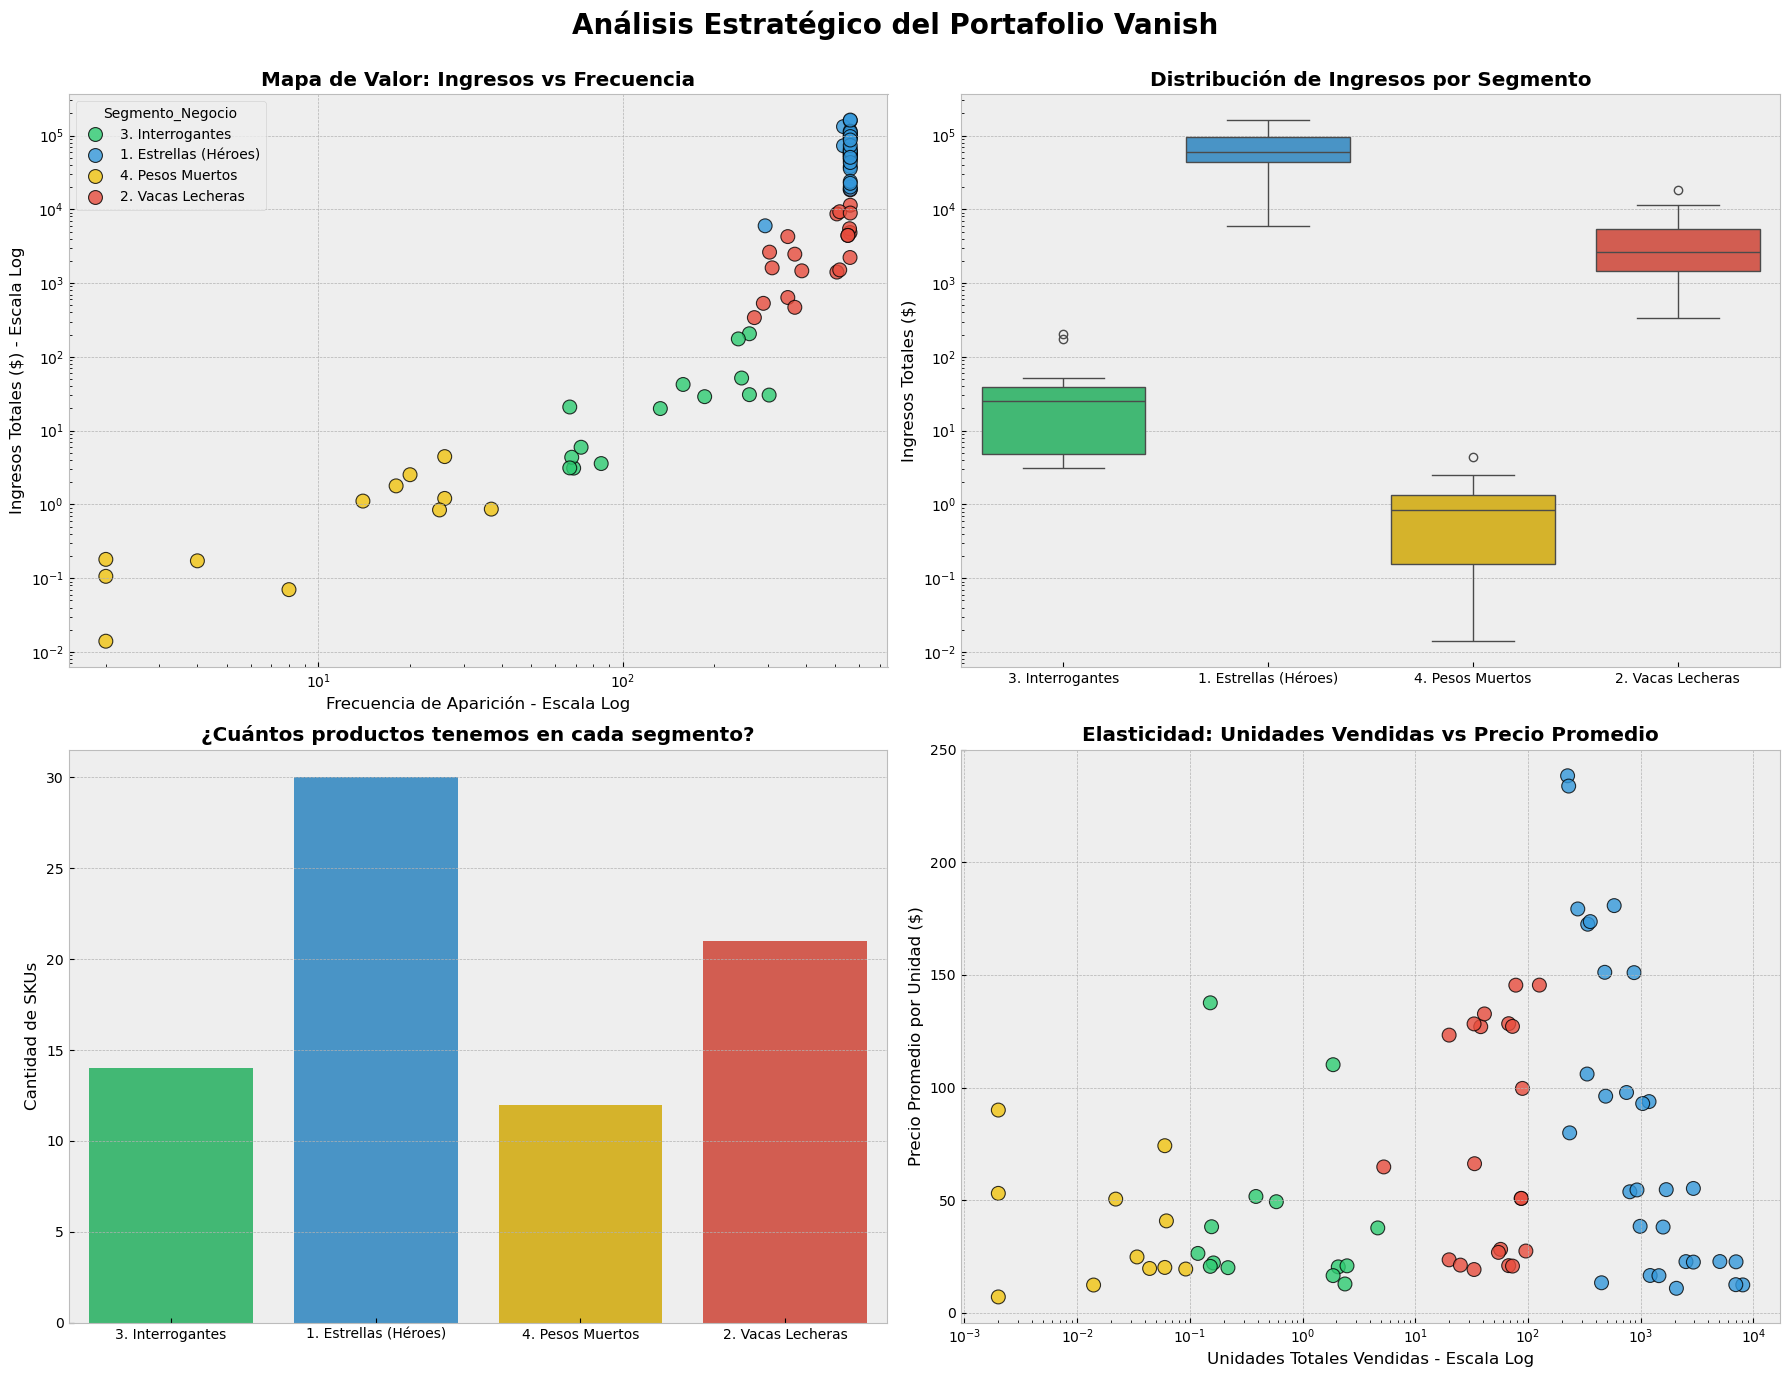

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

def nombrar_portafolio(cluster):
    if cluster == 0: return '1. Estrellas (Héroes)'
    elif cluster == 2: return '2. Vacas Lecheras'
    elif cluster == 1: return '3. Interrogantes'
    elif cluster == 3: return '4. Pesos Muertos'

portafolio_vanish['Segmento_Negocio'] = portafolio_vanish['Cluster'].apply(nombrar_portafolio)


plt.style.use('bmh')
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Análisis Estratégico del Portafolio Vanish', fontsize=20, fontweight='bold')

sns.scatterplot(
    data=portafolio_vanish, 
    x='Frecuencia_Ventas', 
    y='Ingresos_Totales', 
    hue='Segmento_Negocio',
    palette=['#2ecc71', '#3498db', '#f1c40f', '#e74c3c'], 
    s=100, alpha=0.8, edgecolor='black',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Mapa de Valor: Ingresos vs Frecuencia', fontweight='bold')
axes[0, 0].set_yscale('log') 
axes[0, 0].set_xscale('log')
axes[0, 0].set_ylabel('Ingresos Totales ($) - Escala Log')
axes[0, 0].set_xlabel('Frecuencia de Aparición - Escala Log')

sns.boxplot(
    data=portafolio_vanish, 
    x='Segmento_Negocio', 
    y='Ingresos_Totales', 
    palette=['#2ecc71', '#3498db', '#f1c40f', '#e74c3c'],
    ax=axes[0, 1]
)
axes[0, 1].set_title('Distribución de Ingresos por Segmento', fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].set_ylabel('Ingresos Totales ($)')
axes[0, 1].set_xlabel('')


sns.countplot(
    data=portafolio_vanish, 
    x='Segmento_Negocio', 
    palette=['#2ecc71', '#3498db', '#f1c40f', '#e74c3c'],
    ax=axes[1, 0]
)
axes[1, 0].set_title('¿Cuántos productos tenemos en cada segmento?', fontweight='bold')
axes[1, 0].set_ylabel('Cantidad de SKUs')
axes[1, 0].set_xlabel('')

sns.scatterplot(
    data=portafolio_vanish, 
    x='Unidades_Totales', 
    y='Precio_Promedio', 
    hue='Segmento_Negocio',
    palette=['#2ecc71', '#3498db', '#f1c40f', '#e74c3c'],
    s=100, alpha=0.8, edgecolor='black',
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Elasticidad: Unidades Vendidas vs Precio Promedio', fontweight='bold')
axes[1, 1].set_xscale('log')
axes[1, 1].set_ylabel('Precio Promedio por Unidad ($)')
axes[1, 1].set_xlabel('Unidades Totales Vendidas - Escala Log')


plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

In [89]:
pesos_muertos = portafolio_vanish[portafolio_vanish['Segmento_Negocio'] == '4. Pesos Muertos']
print(pesos_muertos)

           ITEM_CODE  Ingresos_Totales  Unidades_Totales  Frecuencia_Ventas  \
4      7501058715029             1.784             0.092                 18   
5      7501058715036             1.206             0.060                 26   
16     7501058716439             0.070             0.000                  8   
17     7501058716446             0.014             0.002                  2   
23     7501058717009             0.864             0.044                 37   
31     7501058753205             0.842             0.034                 25   
41  7501058782694BP1             0.172             0.014                  4   
44     7501058784889             0.106             0.002                  2   
46     7501058788931             2.528             0.062                 20   
47  7501058789778BP1             0.180             0.002                  2   
48  7501058790415BP1             4.450             0.060                 26   
53     7501058793898             1.110             0

In [93]:
pesos_muertos = portafolio_vanish[portafolio_vanish['Segmento_Negocio'] == '4. Pesos Muertos']
print(pesos_muertos['FORMAT'].value_counts())

FORMAT
LIQUIDO    7
POLVO      5
Name: count, dtype: int64


In [99]:
for producto in pesos_muertos['ITEM_DESCRIPTION']:
    print(producto)

VANISH MULTIUSOS REMOVEDOR S/CLORO DE MANCHAS DOYPACK 500ML 7501058715029
VANISH WHITE QUITAMANCHAS Y BLANQ.S/CLORO DOYPACK 500ML 7501058715036
VANISH OXI ACTION GOLD QUITAMANCHAS AHORRO DEL 25% BOT 500GR 7501058716439
VANISH OXI ACTION CRISTAL WHITE AHORRO DEL 25% BOT 500GR 7501058716446
VANISH OXI ACTION ROSA QUITAMANCHAS BOT 120GR 7501058717009
VANISH EXTRA-HIGIENE BOTELLA PLASTICO 900 ML 7501058753205
VANISH OXI ACTION QUITAMANCHAS BOT 450G C/GMM BOT 150GR 7501058782694BP1
VANISH MAX 3 BOT 925ML C /U=2775ML LLEVA 3 PAGA LA MITAD 7501058784889
VANISH MULTIUSOS DUOPACK ROSA QUITA MANCHAS 2BOT 925ML C/U 7501058788931
VANISH EXT HIGIENE REM MANCHAS GAL 4LT + VANISH WHITE 1LT 7501058789778BP1
VANISH ROSA QUITAMANCHAS BOT 450 GR C/G MM BOT 240GR 7501058790415BP1
VANISH ROSA MULTIUSOS REMOVEDOR MANC 3X2 BOT 925MLC/U=2775ML 7501058793898


El análisis de clustering K-Means de nuestro portafolio de 77 SKUs revela que nuestra base de productos regulares (Estrellas y Vacas Lecheras) es extremadamente sana y rentable. Sin embargo, hemos identificado 12 SKUs 'Pesos Muertos' que deben ser eliminados del catálogo maestro de inmediato. Estos no representan un rechazo al formato líquido o en polvo por parte del consumidor, sino que son códigos residuales de promociones expiradas, kits de regalo obsoletos y formatos poco eficientes. Limpiar estos códigos nos ahorrará costos de almacenamiento, evitará confusiones en la cadena de suministro y mejorará el enfoque de nuestros vendedores.